根据每局比赛的过程值预测比赛结果

In [1]:
#%pip install shap
import shap

In [2]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import psutil
import gc
import chess
import chess.engine
import chess.svg
from IPython.display import display, HTML
import subprocess
import time
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as patches
import sqlite3
from matplotlib.patches import ConnectionPatch, Rectangle
from functools import reduce

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

df_moves = pd.read_parquet(r'..\df_moves6.parquet')

In [3]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'Is_check',
       'Is_checkmate', 'Result', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'D', 'Cog_Speed'],
      dtype='object')

In [4]:
df_moves = df_moves[['uid', 'Move_Idx', 'Player', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Move_Time',
       'Game_Length', 'Progress', 'Is_check', 'Is_checkmate', 'Result', 'D', 'Cog_Speed']]
df_moves.head()

,uid,Move_Idx,Player,Is_Error,Is_Blunder,Δi,Δ,ELO,Is_Forced,Is_Optimal,Remain_Time,Move_Time,Game_Length,Progress,Is_check,Is_checkmate,Result,D,Cog_Speed
0,34,1,Dennis Wagner,0,0,3.0,6.0,2802.0,0,1,179.800003,1.2,63,0.015873,0,0,win,0.833333,0.69
1,34,2,Petar Ratkovic,0,0,3.0,4.0,2463.0,0,1,177.800003,3.2,63,0.031746,0,0,lose,0.882353,0.28
2,34,3,Dennis Wagner,0,0,6.0,7.0,2802.0,0,1,178.500000,2.3,63,0.047619,0,0,win,0.810811,0.35
3,34,4,Petar Ratkovic,0,0,14.0,38.0,2463.0,0,0,178.699997,0.1,63,0.063492,0,0,lose,0.441176,NaN
4,34,5,Dennis Wagner,0,0,12.0,15.0,2802.0,0,0,179.199997,0.3,63,0.079365,0,0,win,0.666667,NaN


In [5]:
df_moves['Result'].values

['win', 'lose', 'win', 'lose', 'win', ..., 'draw', 'draw', 'draw', 'draw', 'draw']
Length: 88912034
Categories (3, object): ['draw', 'lose', 'win']

In [6]:
for col in ['uid', 'Player', 'node_score']:
    if col in df_moves.columns:
        if df_moves[col].dtype == 'int64':
            df_moves[col] = pd.to_numeric(df_moves[col], downcast='integer')
        if df_moves[col].dtype == 'float64':
            df_moves[col] = pd.to_numeric(df_moves[col], downcast='float')

In [7]:
def calculate_stage_tm(df_segment, p_stones):
    if df_segment.empty: return pd.DataFrame(columns=['uid', 'Player', 'score'])
    node_scores = []
    for p in p_stones:
        df_segment['dist'] = (df_segment['Progress'] - p).abs()
        idx = df_segment.groupby(['uid', 'Player'], observed=True)['dist'].idxmin()
        target_rows = df_segment.loc[idx].copy()
        target_rows['node_score'] = (target_rows['Time_Residual'] / 180.0) * target_rows['Progress']
        node_scores.append(target_rows[['uid', 'Player', 'node_score']])
    if not node_scores: return pd.DataFrame(columns=['uid', 'Player', 'score'])
    all_nodes = pd.concat(node_scores)
    return all_nodes.groupby(['uid', 'Player'], observed=True)['node_score'].sum().reset_index()

# 1. 算全局残差
time_baseline = df_moves.groupby('Move_Idx')['Remain_Time'].mean().astype('float32')
df_moves['Expected_Remain'] = df_moves['Move_Idx'].map(time_baseline)
df_moves['Time_Residual'] = df_moves['Remain_Time'] - df_moves['Expected_Remain']

# 2. 定义三个阶段的进度锚点
stages = {
    'S1': [0.1, 0.2],
    'S2':  [0.3, 0.4, 0.5],
    'S3':  [0.6, 0.7, 0.8, 0.9]
}

# 3. 循环计算并合并
stage_dfs = []
for name, stones in stages.items():
    # 提取该阶段需要的数据（稍微放宽一点范围防止取不到）
    mask = (df_moves['Progress'] >= min(stones)-0.05) & (df_moves['Progress'] <= max(stones)+0.05)
    slim_df = df_moves.loc[mask, ['uid', 'Player', 'Progress', 'Time_Residual']].copy()
    
    res = calculate_stage_tm(slim_df, stones)
    res.rename(columns={'node_score': f'TM_{name}'}, inplace=True)
    res[f'TM_{name}'] = res[f'TM_{name}'].round(2)
    stage_dfs.append(res.set_index(['uid', 'Player']))

# 4. 合并所有阶段特征并接回原表
game_level_tm = pd.concat(stage_dfs, axis=1).fillna(0).reset_index()
df_moves = df_moves.merge(game_level_tm, on=['uid', 'Player'], how='left')

# 清理内存
del time_baseline, slim_df, stage_dfs, game_level_tm
df_moves.drop(columns=['Expected_Remain', 'Time_Residual'], inplace=True)
gc.collect()

print("分阶段时间管理分计算完成！生成新特征：TM_S1, TM_S2, TM_S3")

分阶段时间管理分计算完成！生成新特征：TM_S1, TM_S2, TM_S3


In [8]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Move_Time', 'Game_Length',
       'Progress', 'Is_check', 'Is_checkmate', 'Result', 'D', 'Cog_Speed',
       'TM_S1', 'TM_S2', 'TM_S3'],
      dtype='object')

In [9]:
df_moves.head()

,uid,Move_Idx,Player,Is_Error,Is_Blunder,Δi,Δ,ELO,Is_Forced,Is_Optimal,...,Game_Length,Progress,Is_check,Is_checkmate,Result,D,Cog_Speed,TM_S1,TM_S2,TM_S3
0,34,1,Dennis Wagner,0,0,3.0,6.0,2802.0,0,1,...,63,0.015873,0,0,win,0.833333,0.69,0.01,0.08,0.72
1,34,2,Petar Ratkovic,0,0,3.0,4.0,2463.0,0,1,...,63,0.031746,0,0,lose,0.882353,0.28,0.01,0.10,-0.02
2,34,3,Dennis Wagner,0,0,6.0,7.0,2802.0,0,1,...,63,0.047619,0,0,win,0.810811,0.35,0.01,0.08,0.72
3,34,4,Petar Ratkovic,0,0,14.0,38.0,2463.0,0,0,...,63,0.063492,0,0,lose,0.441176,NaN,0.01,0.10,-0.02
4,34,5,Dennis Wagner,0,0,12.0,15.0,2802.0,0,0,...,63,0.079365,0,0,win,0.666667,NaN,0.01,0.08,0.72


In [10]:
# 1. 定义阶段划分 (0-0.3 开局, 0.3-0.7 中局, 0.7-1.0 残局)
# 你可以根据需要调整 bins 的数值
bins = [0.0, 0.3, 0.7, 1.0]
labels = ['S1', 'S2', 'S3']

# 2. 给每一步打上阶段标签
df_moves['Stage'] = pd.cut(df_moves['Progress'], bins=bins, labels=labels, include_lowest=True)

# 3. 计算每个 uid + Player 在不同阶段的 Cog_Speed 均值
# 使用 unstack() 直接将 S1, S2, S3 变成列，效率比手动 pivot 高
cog_stage_df = (df_moves.groupby(['uid', 'Player', 'Stage'], observed=True)['Cog_Speed']
                .mean()
                .unstack(fill_value=0) # 如果某局没到残局，填充为0
                .reset_index())

# 重命名列名
cog_stage_df.columns = ['uid', 'Player', 'Cog_Speed_S1', 'Cog_Speed_S2', 'Cog_Speed_S3']

print("分段 Cog_Speed 计算完成！")

分段 Cog_Speed 计算完成！


In [11]:
# result结果映射
result_map = {'win': 1, 'lose': -1, 'draw': 0}
df_moves['Target'] = df_moves['Result'].map(result_map).astype('float32')

# 将单步特征求平均 (mean)，局级特征取第一个值 (first)
# 将单步特征求平均 (mean)，局级特征取第一个值 (first)
game_features = df_moves.groupby(['uid', 'Player'], observed=True).agg({
    'Is_Optimal': 'mean',
    'Is_Error': 'mean', 
    'Is_Blunder': 'mean',
    'Δi': 'mean',          
    'D': 'mean',
    'TM_S1': 'first',  # 新增开局时间管理
    'TM_S2': 'first',   # 新增中局时间管理
    'TM_S3': 'first',   # 新增残局时间管理
    'ELO': 'first',
    'Target': 'first'
}).reset_index()
game_features = game_features.merge(cog_stage_df, on=['uid', 'Player'], how='left')
# 核心特征列表：把 'ELO' 加进来
# 核心特征列表：把 'ELO' 加进来
features_to_diff = [
    'ELO', 'Is_Optimal', 'Is_Error', 'Is_Blunder', 
    'Δi', 'D', 'Cog_Speed_S1', 'Cog_Speed_S2', 'Cog_Speed_S3', 'TM_S1', 'TM_S2', 'TM_S3']
del cog_stage_df
gc.collect()

# 对手信息表
opponent_cols = ['uid', 'Player'] + features_to_diff
opponent_info = game_features[opponent_cols].copy()

rename_dict = {'Player': 'Opponent'}
for col in features_to_diff:
    rename_dict[col] = f'Opp_{col}'
opponent_info.rename(columns=rename_dict, inplace=True)
game_features = game_features.merge(opponent_info, on='uid', how='inner')

# 过滤掉“自己对自己”的行
game_features = game_features[game_features['Player'] != game_features['Opponent']].copy()

# 批量计算 Diff 特征
for col in features_to_diff:
    game_features[f'{col}_Diff'] = game_features[col] - game_features[f'Opp_{col}']

cols_to_drop = [f'Opp_{col}' for col in features_to_diff]
game_features.drop(columns=cols_to_drop, inplace=True)
del opponent_info
gc.collect()
print("加入对抗 Diff 后的特征列：")
print(game_features.columns.tolist())

加入对抗 Diff 后的特征列：
['uid', 'Player', 'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D', 'TM_S1', 'TM_S2', 'TM_S3', 'ELO', 'Target', 'Cog_Speed_S1', 'Cog_Speed_S2', 'Cog_Speed_S3', 'Opponent', 'ELO_Diff', 'Is_Optimal_Diff', 'Is_Error_Diff', 'Is_Blunder_Diff', 'Δi_Diff', 'D_Diff', 'Cog_Speed_S1_Diff', 'Cog_Speed_S2_Diff', 'Cog_Speed_S3_Diff', 'TM_S1_Diff', 'TM_S2_Diff', 'TM_S3_Diff']


In [12]:
game_features = game_features.drop(columns=['Opponent'])
game_features.head()

,uid,Player,Is_Optimal,Is_Error,Is_Blunder,Δi,D,TM_S1,TM_S2,TM_S3,...,Is_Error_Diff,Is_Blunder_Diff,Δi_Diff,D_Diff,Cog_Speed_S1_Diff,Cog_Speed_S2_Diff,Cog_Speed_S3_Diff,TM_S1_Diff,TM_S2_Diff,TM_S3_Diff
1,1,Daniel Barria,0.923077,0.000000,0.000000,2.000000,0.537795,-0.0,0.01,0.22,...,-0.153846,-0.153846,-36.307693,-0.113450,-0.227500,0.0720,-0.422500,-0.0,-0.01,-0.02
2,1,Petra Kejzar,0.846154,0.153846,0.153846,38.307693,0.651245,0.0,0.02,0.24,...,0.153846,0.153846,36.307693,0.113450,0.227500,-0.0720,0.422500,0.0,0.01,0.02
5,2,Jorge Carlos Antonio,0.461538,0.307692,0.230769,788.692322,0.458179,0.0,0.01,-0.06,...,0.236264,0.230769,768.620911,-0.061178,0.038333,-0.1425,NaN,0.0,-0.01,-0.20
6,2,Nataliya Buksa,0.571429,0.071429,0.000000,20.071428,0.519357,-0.0,0.02,0.14,...,-0.236264,-0.230769,-768.620911,0.061178,-0.038333,0.1425,NaN,-0.0,0.01,0.20
9,3,Nikolaos Skiadopoulos,0.736842,0.105263,0.105263,63.578949,0.373199,-0.0,0.04,0.41,...,0.005263,0.055263,32.728951,-0.071206,-0.156000,-0.1675,0.018333,-0.0,0.01,0.11


In [13]:
game_features.columns

Index(['uid', 'Player', 'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D',
       'TM_S1', 'TM_S2', 'TM_S3', 'ELO', 'Target', 'Cog_Speed_S1',
       'Cog_Speed_S2', 'Cog_Speed_S3', 'ELO_Diff', 'Is_Optimal_Diff',
       'Is_Error_Diff', 'Is_Blunder_Diff', 'Δi_Diff', 'D_Diff',
       'Cog_Speed_S1_Diff', 'Cog_Speed_S2_Diff', 'Cog_Speed_S3_Diff',
       'TM_S1_Diff', 'TM_S2_Diff', 'TM_S3_Diff'],
      dtype='object')

In [14]:
game_features.shape

(2014682, 27)

In [15]:
game_features.columns

Index(['uid', 'Player', 'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D',
       'TM_S1', 'TM_S2', 'TM_S3', 'ELO', 'Target', 'Cog_Speed_S1',
       'Cog_Speed_S2', 'Cog_Speed_S3', 'ELO_Diff', 'Is_Optimal_Diff',
       'Is_Error_Diff', 'Is_Blunder_Diff', 'Δi_Diff', 'D_Diff',
       'Cog_Speed_S1_Diff', 'Cog_Speed_S2_Diff', 'Cog_Speed_S3_Diff',
       'TM_S1_Diff', 'TM_S2_Diff', 'TM_S3_Diff'],
      dtype='object')

## 本局特征预测本局结果


运行模式: ALL | 特征数: 7
[LightGBM] [Info] Number of positive: 395647, number of negative: 338769
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1691
[LightGBM] [Info] Number of data points in the train set: 734416, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.538723 -> initscore=0.155204
[LightGBM] [Info] Start training from score 0.155204
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's binary_logloss: 0.399845
准确率: 0.8214 | AUC: 0.8992


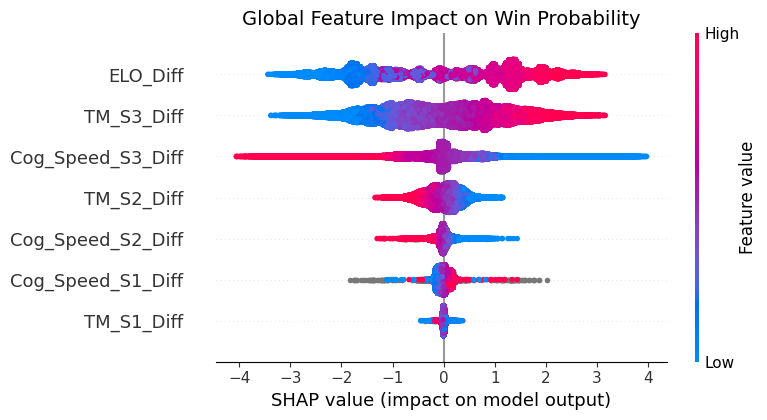

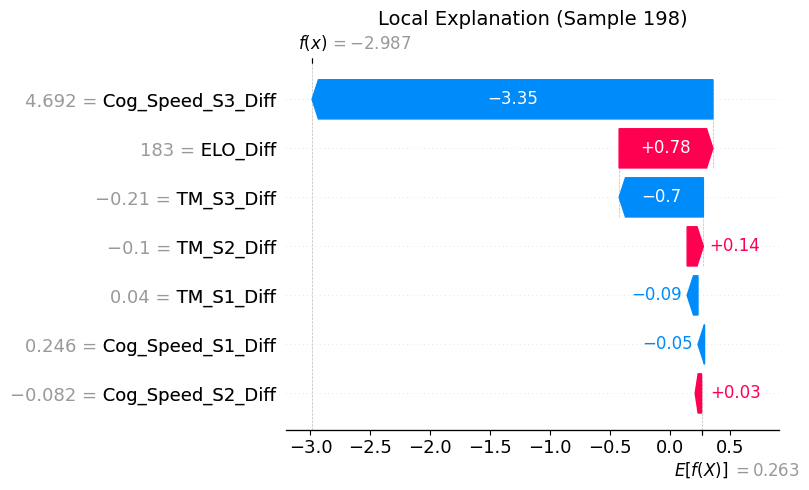


[提示] 当前特征集不包含 ['Cog_Speed_Diff', 'TM_S1', 'TM_S2', 'TM_S3']，跳过该图。

[提示] 当前特征集不包含 ['Cog_Speed_Diff', 'TM_S1', 'TM_S2', 'TM_S3']，跳过该图。

[提示] 当前特征集不包含 ['Cog_Speed_Diff', 'TM_S1', 'TM_S2', 'TM_S3']，跳过该图。

[提示] 当前特征集不包含 ['Cog_Speed_Diff', 'TM_S1', 'TM_S2', 'TM_S3']，跳过该图。


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [16]:
def clean_model_data(df):
    df_c = df[df['Target'] != 0].copy()
    df_c['Target'] = df_c['Target'].apply(lambda x: 1 if x == 1 else 0)
    # 解决数据泄露：每局游戏只取一个视角
    df_c = df_c.groupby('uid').first().reset_index()
    return df_c

df_model = clean_model_data(game_features)

FEATURES_CONFIG = {
    'elo': [#'ELO', 
            'ELO_Diff'],
    'behavior': [
        # 'Cog_Speed_S1', 'Cog_Speed_S2', 'Cog_Speed_S3',
        # 'TM_S1', 'TM_S2', 'TM_S3',
        'Cog_Speed_S1_Diff','Cog_Speed_S2_Diff', 'Cog_Speed_S3_Diff','TM_S1_Diff', 'TM_S2_Diff','TM_S3_Diff',
        #'D', 
        # 'Is_Optimal', 
        # 'Is_Error', 'Is_Blunder' # 根据需要增删
    ]
}

def get_features(mode='all'):
    if mode == 'elo':
        return FEATURES_CONFIG['elo']
    elif mode == 'behavior':
        return FEATURES_CONFIG['behavior']
    elif mode == 'all':
        return FEATURES_CONFIG['elo'] + FEATURES_CONFIG['behavior']
    else:
        raise ValueError("Mode must be 'all', 'elo', or 'behavior'")

# SHAP 分析
def shap_analysis(clf, X_test):
    explainer = shap.TreeExplainer(clf)
    shap_explanation = explainer(X_test) 

    if len(shap_explanation.shape) == 3:
        shap_explanation = shap_explanation[:, :, 1]

    # 图 1：全局蜂群图
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_explanation, max_display=15, show=False) 
    plt.title("Global Feature Impact on Win Probability", fontsize=14)
    plt.tight_layout()
    plt.show()

    # 图 2：单局微观剖析
    sample_idx = 198  
    plt.figure(figsize=(8, 6))
    shap.plots.waterfall(shap_explanation[sample_idx], max_display=10, show=False)
    plt.title(f"Local Explanation (Sample {sample_idx})", fontsize=14)
    plt.tight_layout()
    plt.show()

    # 图 3 & 4：特征依赖图
    features_to_check = ["Cog_Speed_Diff", "TM_S1", 'TM_S2', 'TM_S3']
    
    for feature in features_to_check:
        if feature in X_test.columns:
            plt.figure(figsize=(8, 5))
            
            # 核心改进：直接传入切片。SHAP 会自动检测：
            # 1. X轴：特征原始数值
            # 2. Y轴：SHAP value (贡献度)
            # 3. 颜色：默认就是该特征自身的数值大小 (Red=High, Blue=Low)
            shap.plots.scatter(
                shap_explanation[:, feature], 
                color=shap_explanation[:, feature], # 强制指定自身为颜色基准
                show=False
            )
            
            plt.title(f"Marginal Effect of {feature} (Self-Colored)", fontsize=12)
            plt.grid(alpha=0.2) # 加点网格线，论文图更好看
            plt.tight_layout()
            plt.show()
        else:
            print(f"\n[提示] 当前特征集不包含 {features_to_check}，跳过该图。")

def run_experiment(df = df_model, mode='all'):
    features = [f for f in get_features(mode) if f in df_model.columns]
    X = df[features]
    y = df['Target']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print(f"\n" + "="*40)
    print(f"运行模式: {mode.upper()} | 特征数: {len(features)}")
    print("="*40)

    clf = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(50)])
    
    # 评估与 SHAP 分析 (调用你原有的 shap_analysis 函数)
    y_prob = clf.predict_proba(X_test)[:, 1]
    print(f"准确率: {accuracy_score(y_test, clf.predict(X_test)):.4f} | AUC: {roc_auc_score(y_test, y_prob):.4f}")
    
    shap_analysis(clf, X_test) 
    return clf

run_experiment(df = df_model, mode='all')


运行模式: ELO | 特征数: 1
[LightGBM] [Info] Number of positive: 395647, number of negative: 338769
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000633 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 734416, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.538723 -> initscore=0.155204
[LightGBM] [Info] Start training from score 0.155204
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[117]	valid_0's binary_logloss: 0.50759
准确率: 0.7676 | AUC: 0.8280


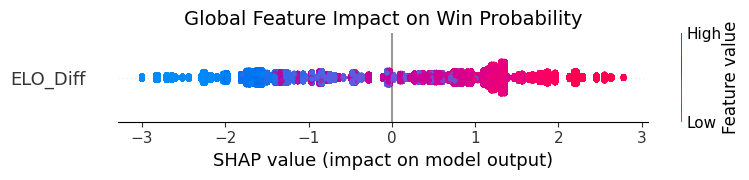

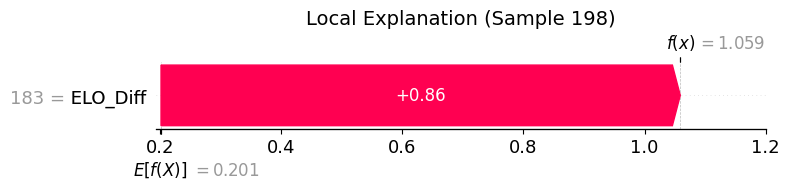


[提示] 当前特征集不包含 ['Cog_Speed_Diff', 'TM_S1', 'TM_S2', 'TM_S3']，跳过该图。

[提示] 当前特征集不包含 ['Cog_Speed_Diff', 'TM_S1', 'TM_S2', 'TM_S3']，跳过该图。

[提示] 当前特征集不包含 ['Cog_Speed_Diff', 'TM_S1', 'TM_S2', 'TM_S3']，跳过该图。

[提示] 当前特征集不包含 ['Cog_Speed_Diff', 'TM_S1', 'TM_S2', 'TM_S3']，跳过该图。


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [17]:
run_experiment(df = df_model, mode='elo')


运行模式: BEHAVIOR | 特征数: 6
[LightGBM] [Info] Number of positive: 395647, number of negative: 338769
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001878 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1436
[LightGBM] [Info] Number of data points in the train set: 734416, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.538723 -> initscore=0.155204
[LightGBM] [Info] Start training from score 0.155204
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[298]	valid_0's binary_logloss: 0.516536
准确率: 0.7414 | AUC: 0.8202


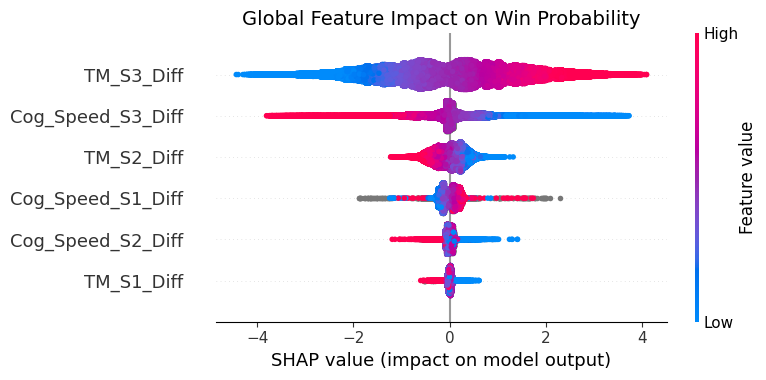

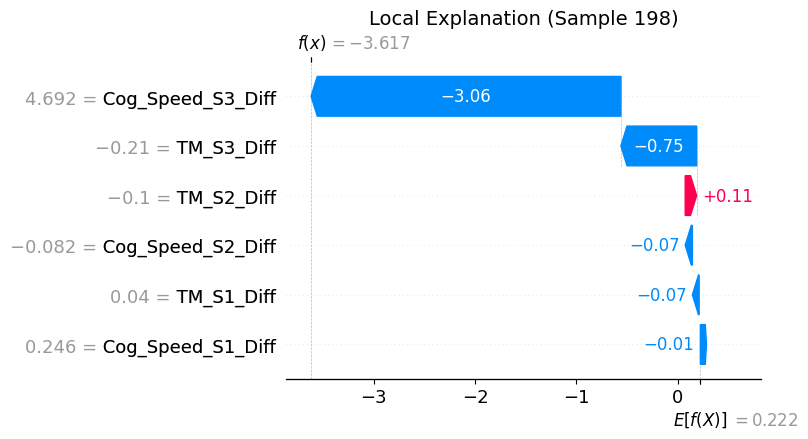


[提示] 当前特征集不包含 ['Cog_Speed_Diff', 'TM_S1', 'TM_S2', 'TM_S3']，跳过该图。

[提示] 当前特征集不包含 ['Cog_Speed_Diff', 'TM_S1', 'TM_S2', 'TM_S3']，跳过该图。

[提示] 当前特征集不包含 ['Cog_Speed_Diff', 'TM_S1', 'TM_S2', 'TM_S3']，跳过该图。

[提示] 当前特征集不包含 ['Cog_Speed_Diff', 'TM_S1', 'TM_S2', 'TM_S3']，跳过该图。


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [18]:
run_experiment(df = df_model, mode='behavior')

In [19]:
df_test = df_model.copy()
# 随机打乱时间管理特征
df_test['TM_S3_Diff'] = np.random.permutation(df_test['TM_S3_Diff'])

X = df_test[['TM_S3_Diff']]
y = df_test['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = lgb.LGBMClassifier(random_state=42)
clf.fit(X_train, y_train)
print(f"打乱后准确率: {accuracy_score(y_test, clf.predict(X_test)):.4f}")

[LightGBM] [Info] Number of positive: 395647, number of negative: 338769
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000601 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 734416, number of used features: 1
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.538723 -> initscore=0.155204
[LightGBM] [Info] Start training from score 0.155204
打乱后准确率: 0.5380


## 选手的历史特征，预测新的比赛结果

In [20]:
# 匹配上日期信息
import sqlite3
db_path = r'C:\sqlite3\chess.db'
conn = sqlite3.connect(db_path)

# 仅提取必要的 uid 和 Date 列
query = "SELECT uid, Date FROM games"
df_dates = pd.read_sql_query(query, conn)
conn.close()

# 将日期信息合并到 game_features 
game_features = pd.merge(game_features, df_dates, on='uid', how='left')
game_features['Date'] = pd.to_datetime(game_features['Date'], format='%Y.%m.%d', errors='coerce')

# 检查是否有缺失日期
missing_dates = game_features['Date'].isna().sum()
if missing_dates > 0:
    print(f"警告：有 {missing_dates} 局游戏未能匹配到日期信息。")

In [21]:
game_features.head()

,uid,Player,Is_Optimal,Is_Error,Is_Blunder,Δi,D,TM_S1,TM_S2,TM_S3,...,Is_Blunder_Diff,Δi_Diff,D_Diff,Cog_Speed_S1_Diff,Cog_Speed_S2_Diff,Cog_Speed_S3_Diff,TM_S1_Diff,TM_S2_Diff,TM_S3_Diff,Date
0,1,Daniel Barria,0.923077,0.000000,0.000000,2.000000,0.537795,-0.0,0.01,0.22,...,-0.153846,-36.307693,-0.113450,-0.227500,0.0720,-0.422500,-0.0,-0.01,-0.02,2025-04-01
1,1,Petra Kejzar,0.846154,0.153846,0.153846,38.307693,0.651245,0.0,0.02,0.24,...,0.153846,36.307693,0.113450,0.227500,-0.0720,0.422500,0.0,0.01,0.02,2025-04-01
2,2,Jorge Carlos Antonio,0.461538,0.307692,0.230769,788.692322,0.458179,0.0,0.01,-0.06,...,0.230769,768.620911,-0.061178,0.038333,-0.1425,NaN,0.0,-0.01,-0.20,2025-04-01
3,2,Nataliya Buksa,0.571429,0.071429,0.000000,20.071428,0.519357,-0.0,0.02,0.14,...,-0.230769,-768.620911,0.061178,-0.038333,0.1425,NaN,-0.0,0.01,0.20,2025-04-01
4,3,Nikolaos Skiadopoulos,0.736842,0.105263,0.105263,63.578949,0.373199,-0.0,0.04,0.41,...,0.055263,32.728951,-0.071206,-0.156000,-0.1675,0.018333,-0.0,0.01,0.11,2025-04-01


In [22]:
game_features.columns

Index(['uid', 'Player', 'Is_Optimal', 'Is_Error', 'Is_Blunder', 'Δi', 'D',
       'TM_S1', 'TM_S2', 'TM_S3', 'ELO', 'Target', 'Cog_Speed_S1',
       'Cog_Speed_S2', 'Cog_Speed_S3', 'ELO_Diff', 'Is_Optimal_Diff',
       'Is_Error_Diff', 'Is_Blunder_Diff', 'Δi_Diff', 'D_Diff',
       'Cog_Speed_S1_Diff', 'Cog_Speed_S2_Diff', 'Cog_Speed_S3_Diff',
       'TM_S1_Diff', 'TM_S2_Diff', 'TM_S3_Diff', 'Date'],
      dtype='object')

In [23]:
game_features.to_parquet('game_features.parquet')

In [24]:
# 排序：确保时间顺序
df = game_features.sort_values(by=['Player', 'Date', 'uid']).reset_index(drop=True)

# 定义需要计算历史状态的基础特征
# 2. 定义需要计算历史状态的基础特征
base_features = [
    'Δi', 'D', 
    'Is_Optimal', 'Is_Error', 'Is_Blunder', 
    'Cog_Speed_S1', 'Cog_Speed_S2', 'Cog_Speed_S3', 'TM_S1', 'TM_S2', 'TM_S3',
    ]

# 简化的历史特征列名
historical_cols = [f"{col}_Hist" for col in base_features]
df[historical_cols] = df.groupby('Player')[base_features].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=10).mean()
)
df_model = df.dropna(subset=historical_cols).copy()

# 提取必需列并自连接合并对手信息，在提取必需列时加上 Date
cols_to_keep = ['uid', 'Player', 'ELO', 'Target', 'Date'] + historical_cols
df_base = df_model[cols_to_keep]

# 合并逻辑
df_match = pd.merge(
    df_base, 
    df_base, 
    on='uid', 
    suffixes=('', '_Opp')
)
df_match = df_match[df_match['Player'] != df_match['Player_Opp']].copy()
# 同一局比赛 uid 相同，Date 也相同，保留一个 Date 即可，删掉 Date_Opp
if 'Date_Opp' in df_match.columns:
    df_match.drop(columns=['Date_Opp'], inplace=True)
# 再次按时间全局排序
df_match = df_match.sort_values(by=['Date', 'uid']).reset_index(drop=True)

# 算差值
df_match['ELO_Diff'] = df_match['ELO'] - df_match['ELO_Opp']
for col in base_features:
    hist_col_self = f"{col}_Hist"
    hist_col_opp = f"{col}_Hist_Opp"
    diff_col_name = f"{col}_Hist_Diff"
    
    df_match[diff_col_name] = df_match[hist_col_self] - df_match[hist_col_opp]

# 现在的 df_match 就符合命名期望

C:\Users\Administrator\AppData\Local\Temp\ipykernel_8880\1133295919.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[historical_cols] = df.groupby('Player')[base_features].transform(


In [25]:
df_match.to_parquet('df_match.parquet')

In [26]:
df_match.columns

Index(['uid', 'Player', 'ELO', 'Target', 'Date', 'Δi_Hist', 'D_Hist',
       'Is_Optimal_Hist', 'Is_Error_Hist', 'Is_Blunder_Hist',
       'Cog_Speed_S1_Hist', 'Cog_Speed_S2_Hist', 'Cog_Speed_S3_Hist',
       'TM_S1_Hist', 'TM_S2_Hist', 'TM_S3_Hist', 'Player_Opp', 'ELO_Opp',
       'Target_Opp', 'Δi_Hist_Opp', 'D_Hist_Opp', 'Is_Optimal_Hist_Opp',
       'Is_Error_Hist_Opp', 'Is_Blunder_Hist_Opp', 'Cog_Speed_S1_Hist_Opp',
       'Cog_Speed_S2_Hist_Opp', 'Cog_Speed_S3_Hist_Opp', 'TM_S1_Hist_Opp',
       'TM_S2_Hist_Opp', 'TM_S3_Hist_Opp', 'ELO_Diff', 'Δi_Hist_Diff',
       'D_Hist_Diff', 'Is_Optimal_Hist_Diff', 'Is_Error_Hist_Diff',
       'Is_Blunder_Hist_Diff', 'Cog_Speed_S1_Hist_Diff',
       'Cog_Speed_S2_Hist_Diff', 'Cog_Speed_S3_Hist_Diff', 'TM_S1_Hist_Diff',
       'TM_S2_Hist_Diff', 'TM_S3_Hist_Diff'],
      dtype='object')

## 根据选手的历史特征，去预测新的比赛结果
### 在 res_pred2.ipynb 文件里